One more time....

In [ ]:
%pip install qiskit qiskit-ibm-runtime qiskit-aer
!pip install pylatexenc matplotlib

# 22. Final Project (Start)

## A final project on simulating something "like electrons and positrons"

## Objectives:

* Gain familiarity with simulating quantum systems through trotterization
* Using all your accrued skills, implement a novel code on a real device
* Perform statistical analysis on noisy data

This lab is a vain attempt to extend some of the work performed in <font color='blue'>https://arxiv.org/abs/1903.08807</font> to actual machines. I have tried to inject this with as much of the real feel of doing work on quantum algorithms today as possible.  Typically, each year some of our year-long interns take this code and extend it in some way...see https://journals.aps.org/pre/abstract/10.1103/PhysRevE.109.015307

## The Model: 1+1d $Z_2$ gauge theory with staggered fermionic matter

During Hersh's lecture, he mentioned that one method for studying quantum systems is to construct a model _Hamiltonian_ that we hope will capture the important static and dynamic properties of the system we care about. You are perhaps familar with electromagnetic waves and charged particles.  

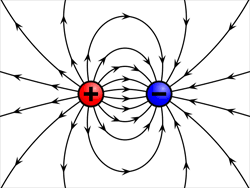

As you probe systems with these degrees of freedom at smaller and smaller scales, you eventually need to consider quantum mechanics.  Then, you become interested in the _quanta_ of each.  Neglecting the nuclei, this becomes a theory about photons ( the quanta of light) and electrons (a quanta of charge).  

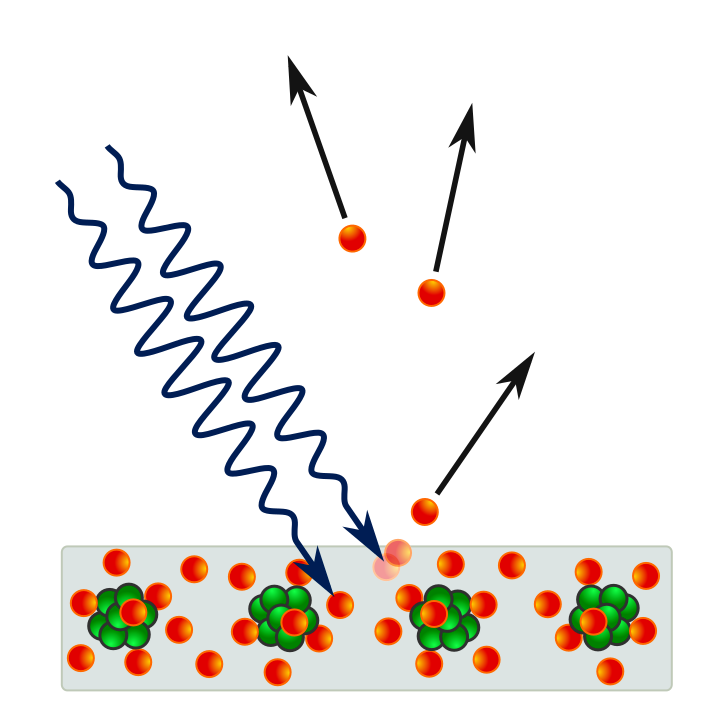

If you want to probe the system at increasing small scales or high energies, consistence of the theory with the theory of relativty will become important.  At this point, you will discover that you are forced to introduce a antimatter (particles with opposite charge, but same mass) into your theory.  At this point, you would be working with Quantum Electrodynamics (QED), the quantum field theory of particles and antiparticles that interact via the photon.

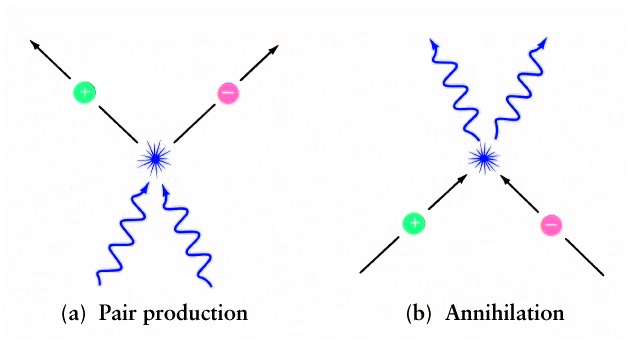

As has been mentioned a few times in this school, many of your instructors work on _lattice field theory_.  This is when you take a quantum field theory, and compute it's properties by discretizing spacetime (This is a relativistic theory, so we got to treat space and time the same) into finite space and time steps.  For technical reasons, the way to place QED on the lattice is to place the electrons and positrons onto the lattice sites, and the photons onto the links between the sites.  In the example below, I have drawn a 3 dimensional lattice of lengths 4x2x2:

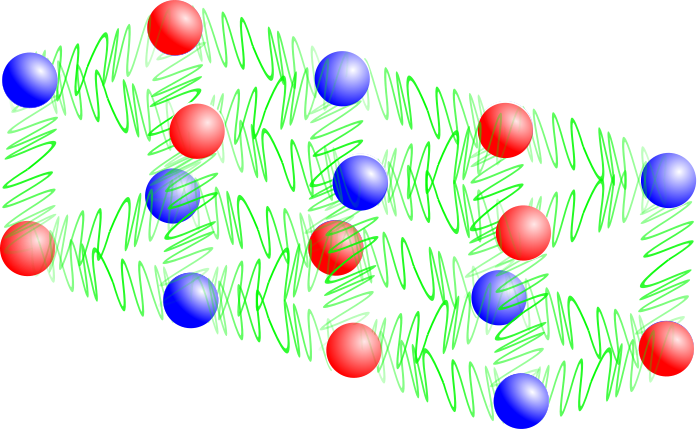

Now, electrons and positrons are both _fermions_ which are particles that aren't allowed to every be in the same place at once. When you discretize spacetime, it turns out there are many ways to represent your fermions on lattice sites.  In this lab, we will take the _staggered_ formulation -- this is heuristically placing electrons and positrons on alternating sites. So any given lattice site has either 0 or 1 fermion.  In contrast, photons are _bosons_ which can have as many of themselves in any place at once.  The result of this (with an additional complication) is that each link of the lattice should be able to store a complex number-- a much larger computational cost!

Let's take a crack at estimating the computational resources need to do a lattice QED (LQED) calculation:

In [2]:
#We live in 3 space and 1 time dimension, so lets make a variable
#to sort the spacetime dimension, d= (space dimensions)+(time dimesions)
d=4

#Now, lets consider the length of one side of our hypercube.  These days, its not uncommon to have
#lengths, L, of over 100 sites.  Let's use that as our estimate and sort it as L
L=100

#With these numbers, we should have L**d lattice sites.  Lets store this as N_s.
#Notice how quickly this grows with large numbers of dimension
N_s=L**d

#Now, for each lattice site, we can assign d links uniquely to it, in order to
#determine N_l=d*N_s, the total number of links
N_l=d*N_s

#For each lattice site and fermion, we need 1 bit, while for each lattice link for our photons we will take 64-bit double precision numbers
#and since we need a complex number, we need 2 of them, so N_lbits=128 bits are required for each link.
N_lbits=128

# So the total number of bits is N_bits=N_s+N_lbits*N_l
N_bits=N_s+N_lbits*N_l

#To roughly convert to gigabytes, N_gb, we divide N_bits by 8*1e9
N_gb = N_bits/(8*1e9)

#At this point, print out your estimate for the number of gigabytes,
#and number of bits to do store this LQED simulation:
print("Memory Requirements for our lattice: ",N_gb, "GB")
print("Memory Requirements for our lattice: ",N_bits, "b")

Memory Requirements for our lattice:  6.4125 GB
Memory Requirements for our lattice:  51300000000 b


* What do you think of these numbers?  
* Are they large or small compared to your computer's memory?  
* Do you think you could perform a calculation of this size on your computer?

Now for the obvious question:
* <b>How does this compare to the size of existing quantum computers?</b>

Presumably, you realize that quantum devices, even if noiseless, are currently far to small to do a comparable calculation today.  This is where approximating our model of QED can come in.  By chosing different parameters, perhaps we can get down to a size tractable on todays machines.

*In the cell below, try and find some set of parameters that requires less than say, 100 qubits.  Thats something we could dream about running in the next few years. <b>Helpfully on a quantum computer, we typically only need to store the _space_ lattice </b>, so we need 1 less dimension than the classical computer.

In [3]:
#Maybe we don't work in 3 space dimensions initally?
d=1

#Maybe we don't use quite as large of a box?
L=50


#We can't really change the number of sites or links once we specify dimension and length
N_s=L**d
N_l=d*N_s

#For each lattice site, we need 1 bit, so we can't really reduce this without just removing
#the electrons and positrons from the theory.  That seems like an extreme approximation!!! Probably
# best not to do that.

#On the other hand, those 2 64-bit double precision numbers for the photons are pretty expensive,
#perhaps we can do something to reduce them?
N_lbits=1

N_bits=N_s+N_lbits*N_l

#To roughly convert to gigabytes, N_gb, we divide N_bits by 8*1e9
N_gb = N_bits/(8*1e9)

#At this point, print out your estimate for the number of gigabytes,
#and number of bits to do store this LQED simulation:
print("Memory Requirements for our lattice: ",N_gb, "GB")
print("Memory Requirements for our lattice: ",N_bits, "b")

Memory Requirements for our lattice:  1.25e-08 GB
Memory Requirements for our lattice:  100 b


So what did you discover?  Probably that we have to do some pretty extreme approximations to get to something below a hundred qubits.  In order to run something on a real device, we will be making the making the most extreme of these approximations, setting the number of space dimensions to 1 (so we are working with 1+1d theory were the first number counts space dimensions and the second counds time dimensions.)  Further, we will only be taking  2 lattice sites into account.  So our picture has changed from the one above to:

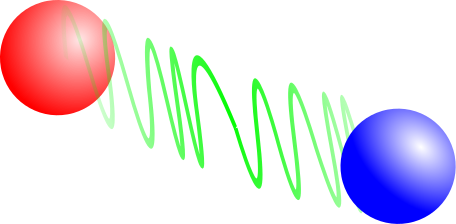

While physicists know pretty well how lowering the number of dimensions and the length of the box effect our results, it is in fact a relatively open question about how reducing the number of qubits per photon link effects our predictions (Many of your instructors spend inordinant amounts of time studying this _digitization_ question)

Because the photon link can be represented by a complex number (for the mathematically minded, its related to the $U(1)$ group), its possible to think of its value as taking values on circle (the left in the picture):

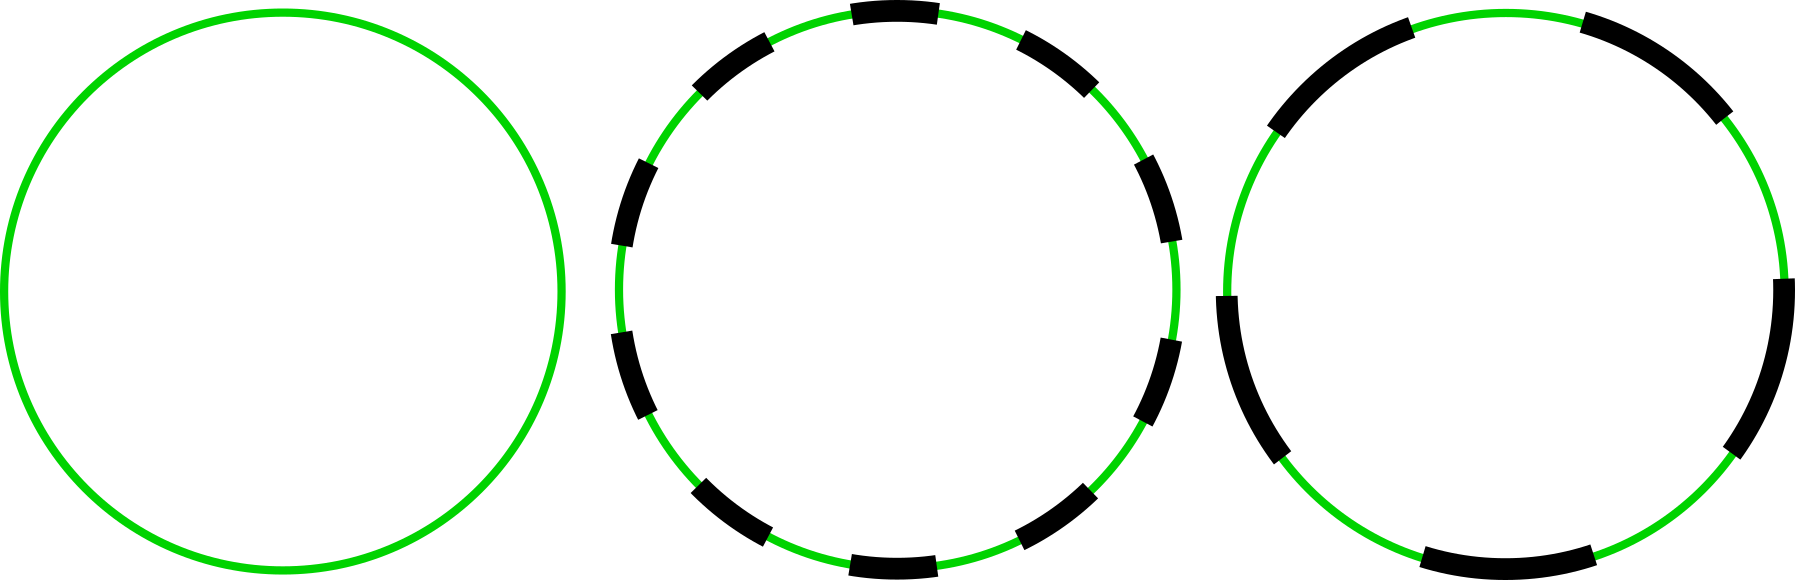

One way to reduce the number of qubits needed for the photon link, which I have a particular affinity for, is to replace the circle on the left by a finite set of evenly selected points on it (picture on the right).  In this situation, we are formally replacing the U(1) group by the $Z_n$ group, where $n$ is the number of points on the circle.  In this way, you can imagine reducing the number of qubits from 2 complex numbers to a single integer, $n$.  In this lab, we will take the maximally harsh approximation of replacing the nearly continuous circle by 2 points, leading to the $Z_2$ part of the title.  In this approximation, we can represent the photon by a single qubit.

So all together, the model we will consider in this lab _1+1d $Z_2$ gauge theory with staggered matter_ will involve 1 electron, 1 positron, and 1 $Z_2$-valued photon.  This leads to <b>a system of 3 qubits</b>, and we will need 1 additional ancilla qubit in order to perform some of the time-evolution.

## The Hamiltonian

The lattice Hamiltonian for this model is

$$H = \frac 1 2 \sigma^{(x)} + 2 \bar{p}\sigma^{(z)}e
-m\bar p p +m\bar{e}e$$
where

* $e$ is a one-component electron (which we put in qubit 0)
* $p$ is a one-component positron (which we put in qubit 2)
* $\bar{e}$ and $\bar{p}$ indicate their complex conjugate transpose
* $\sigma$ is the photon, with the superscript indicated which basis it is acted on in (which we put in qubit 1)
* The first term is the kinetic energy for the photon
* The second term is the kinetic energy for the electron/positron--which in the lab we call a hopping term
* The final term gives the electron or positron a mass, $m$


Using the something called <font color='blue'>[Jordan-Wigner procedure](https://docs.microsoft.com/en-us/azure/quantum/user-guide/libraries/chemistry/concepts/jordan-wigner)</font>, we translate from the fermions into a set of bosons.  This write us to right the Hamiltonian above nicely in terms of gates:
$$
H = \frac{m}{2}Z_{e}-\frac{m}{2} Z_{p}
+\frac{X_{\gamma}}{2}+\frac{1}{4}Z_{\gamma} \left(X_{e}X_{p}+Y_e Y_{p}\right)
$$

The subscripts indicate which of the 3 qubits a given gate is acting on (the electron $e$, the positron $p$, or the photon $\gamma$)

## Time Evolution

With this Hamiltonian, we could act on a state $|\psi\rangle$ in the Schrodinger equation:

$$i\partial_t |\psi(t)\rangle=H |\psi(t)\rangle$$

Now remember, $H$ isn't a unitary matrix, its only Hermitian.  This means we can't use it trivally on a quantum computer. If we want to time evolve a give state $|\psi_0\rangle$, we should follow Hersh's lectures and use the time evolution operator $U=e^{-iHt}$ to get

$$ |\psi(t)\rangle = U|\psi_0\rangle=e^{-iHt}|\psi_0\rangle$$

Thinking back to Hersh's lecture, we remember that $H$ often has non-commuting terms, which prevents the gate $U$ from being efficiently built into a circuit.  The method of _trotterization_ allows us approximate the $U$ in a way that is efficient.  In our case, there are 3 terms in our Hamiltonian:

$$ H = H_{kg} + H_{fh} + H_{m} $$

* $H_{kg}$ is the kinetic term for the photon
* $H_{fh}$ is the fermionic hopping term
* $H_{m}$ is the fermionic mass terms

In this case, we can approximate $U$ by:

$$\Large U=e^{-iHt}\approx \left(e^{-iH_{kg}\epsilon}e^{-iH_{fh}\epsilon}e^{-iH_{m}\epsilon}\right)^{t/\epsilon}+O(\epsilon^2)\equiv (U_\epsilon)^{N} $$
where $N=t/\epsilon$ is the number of time steps we want to use. With this, we can now write $U_\epsilon$ in terms of gates:

$$\Large{ U_{\epsilon}=e^{-iH_{kg}\epsilon}e^{-iH_{fh}\epsilon}e^{-iH_{m}\epsilon}
\\     =e^{-i\epsilon X_\gamma/2}e^{-i\frac{\epsilon}{4}Z_{\gamma} \left(X_{e}X_{p}+Y_e Y_{p}\right)}e^{-i(-1)^j m \epsilon Z_j/2} }$$
where $j={e=0,p=1}$
Now, the first and last gates should look familar to you as general rotation gates in the $X,Z$ directions:

$${ e^{-i\epsilon X_\gamma/2}=RX(\epsilon)
    e^{-i(-1)^j m \epsilon Z_j}=RZ((-1)^{j+1}m\epsilon )} $$

The final term, fermion hopping $U_{fh}$, is by far the hardest and most non-trivial gate.  One way to implement it is similar to the quantum adder, where we use an ancilla qubit.  

For the $XZX$ term, you diagonalize the fermions into the $X$ basis using $H$, apply CNOTs to the ancilla with the control being the electron, photon, and positron, perform a $RZ(-(-1)^j\epsilon/4)$ the redo the CNOT and $H$ gates.  

Fror the $YZY$ term, we do the same thing except the

$$U(\phi,\theta,\lambda)=RZ(\phi)𝑅X(−\pi/2)RZ(𝜃)RX(\pi/2)𝑅𝑍(\lambda)$$

gate is used to diagonalize, with $\phi=\lambda=-\pi/2$ and $\theta=\pi/2$.  Unlike the Hadamard for which $H^{-1}=H$, To reverse the $U(-\pi/2,\pi/2,-\pi/2)$, we need to use $U(\pi/2,\pi/2,-\pi/2)$

Defining a gate $RZ3$ as the collection of CNOTs and the $RZ$ gate, this gate looks like:

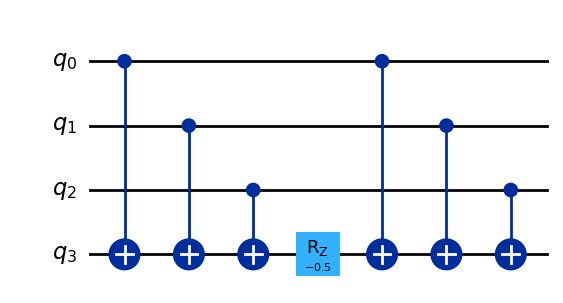

from which we can get the $U_{fh}$ as:

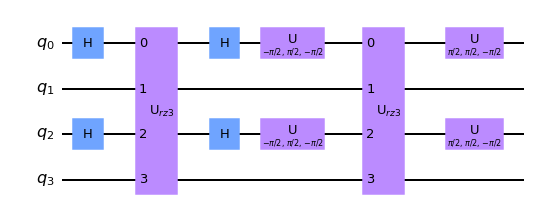

## ...Ready for it?

So first of, lets of course set up all the imports that we need:

* numpy
* import everything from qiskit and its various packages: `QuantumCircuit,transpile, generate_preset_pass_manager, GenericBackendV2, AerSimulator, SamplerV2` as Sampler, `QiskitRuntimeService` and `plot_histograms`
* Make sure you have $\pi$

In [4]:
import numpy as np

# Importing standard Qiskit libraries
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService

# import basic plot tools
from qiskit.visualization import plot_histogram

from math import pi
import matplotlib.pyplot as plt

Next, you neeed to load your IBMQ account, and set your token

In [5]:
# To run on real IBM hardware, paste your API token below and the helper will
# connect to the IBM Quantum runtime. If no token / no network is available, the
# helper transparently falls back to a local AerSimulator so the lab still runs.
token = ''  # <-- paste your IBM Quantum API token here to use real hardware
instance = ''

def get_backend(simulator_fallback=True):
    """Return a backend to run on.

    Tries the IBM Quantum runtime and the least-busy *real* device; on any
    failure (no token, no network, no account) falls back to AerSimulator()
    so the notebook is runnable locally. The real-hardware path is kept visible
    above the fallback.
    """
    try:
        if token:
            QiskitRuntimeService.save_account(
                token=token,
                instance=instance,
                overwrite=True
            )
        service = QiskitRuntimeService()
        backend = service.least_busy(simulator=False)   # REAL hardware
        print(f">>> Using IBM backend: {backend.name}")
        return backend, service
    except Exception as exc:
        if not simulator_fallback:
            raise
        print(f">>> IBM runtime unavailable ({type(exc).__name__}); "
              f"falling back to AerSimulator().")
        return AerSimulator(), None

backend, service = get_backend()

>>> IBM runtime unavailable (AccountNotFoundError); falling back to AerSimulator().


While we are only going to simulate the 2-site (4 qubit) model, the code we are going to write will be general enough that if you had a better quantum computer, you would be able to trivially rerun our model for a larger number of sites.  For this reason, we need to define the basic parameters of the theory we are interested in.  There are three:

* `N` which is the number of sites of the lattice (The total number of qubits is 2N = N sites + N-1 links + 1 ancilla).  Set this to 2.
* `epsilon` which is the trotterized time step.  For now, set this to 0.5.
* Besides these numerical parameters, there is a physical parameter `m` which determines the mass of the electron and positron.  For now, set this to 0.10.

In [6]:
# Number of sites
N = 2
epsilon = 0.5
mass = 0.10

## Gauge Kinetic Gate
For our first task, lets create a function that will creat the gauge kinetic gate.  This function should take in `epsilon` and return a gate $U_kg$ that can be appended to a quantum circuit later.

While there is some setup and clean up lines of code you need to use, the important part is that the gate the should be returned should be:

$$RX(\epsilon)$$

In [7]:
#define gauge_kinetic to take in only epsilon
def gauge_kinetic(epsilon):
    #create a circuit, since this gate only ever works on 1 qubit, your circuit need only 1 qubit
    circuit = QuantumCircuit(1)
    #apply the correct gate to your circuit
    circuit.rx(epsilon, 0)
    #turn the circuit into a gate, U_kg
    U_kg = circuit.to_gate()
    #Name your gate something useful for looking at the circuits later
    U_kg.name = "U$_{Kg}$"
    #return your gate
    return U_kg

In the next cell, create a circuit and test that your implementation for gauge_kinetic works by drawing the circuit.  Remember that when using `append` to add gates, you need to pass in also a list of qubits to apply it to.

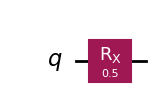

In [8]:
qc = QuantumCircuit(1)
qc.append(gauge_kinetic(epsilon), [0])
qc.decompose().draw('mpl')

Before proceeding, you might notice that while this circuit properly prints $U_kg$, it doesn't tell you if $U_kg$ is doing what you want.  If instead of `draw()`, you use `circuit.decompose().draw()` to reduce your gates to more standard ones.

## Fermion mass gate

For the `fermion_mass` function we can mostly repeat the syntax used for the `gauge_kinetic` to create another gate.  In this case we want to do:

$$RZ((-1)^{j+1}m\epsilon ) $$

For this function, take in `epsilon`, `mass`, and `eta`.  The `eta` will be used pass into the circuit the value $(-1)^{j+1}$

In [9]:
def fermion_mass(epsilon, mass, eta):
    circuit = QuantumCircuit(1)
    circuit.rz(-epsilon * mass * eta, 0)
    U_m = circuit.to_gate()
    U_m.name = "U$_m$"
    return U_m

Again, it's important to _unit test_ each function before proceeding.  So implement a test circuit for `fermion_mass` where you pass in the stored variables, and for `eta` use 1

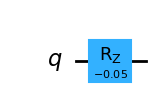

In [10]:
qc = QuantumCircuit(1)
qc.append(fermion_mass(epsilon, mass, 1), [0])
qc.decompose().draw('mpl')

## Fermion hopping term

Now for the complicated set of gates.  Program a function that will return a gate that does the following, but takes an arbitrary angle

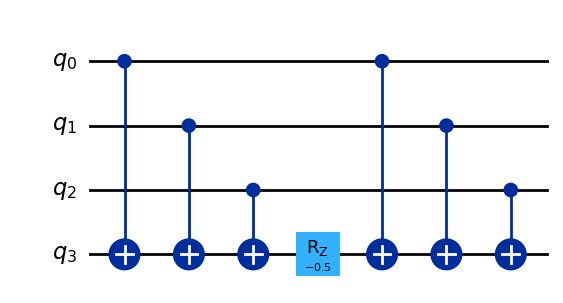

This function `rz3` needs to take in an angle `theta` and return `U_rz3`.  To work correctly, you will need to create a circuit inside this function with 4 qubits

In [11]:
def rz3(theta):
    circuit = QuantumCircuit(4)
    circuit.cx(0, 3)
    circuit.cx(1, 3)
    circuit.cx(2, 3)
    circuit.rz(theta, 3)
    circuit.cx(0, 3)
    circuit.cx(1, 3)
    circuit.cx(2, 3)
    U_rz3 = circuit.to_gate()
    U_rz3.name = "U$_{rz3}$"
    return U_rz3

Now that we have a very complicated gate, we should definitely test it, decompose the gate, and draw it to check.  For the argument of `rz3` pass it `-2*epsilon`

Hopefully this exactly agrees with the circuit above.

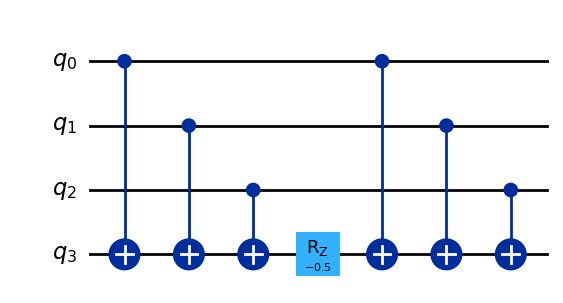

In [12]:
qc = QuantumCircuit(4)
qc.append(rz3(-epsilon), range(4))
qc.decompose().draw('mpl')

The final gate we need is the $U_{fh}$, which is built from the $RZ3$.  This function should take in `epsilon` and `eta`
![fh_gate.png](attachment:fh_gate.png)

You also need Hadamard around 1 of the $RZ3$ gates and U gates around the other.  For arguments, the $RZ3$ gate should take in `-epsilon/4*eta`.  Remember that to use self-made gates, you need to use `circuit.append(gate,list_of_qubits_acted_on)`

<b>Remember that the U gate is not its own inverse, so you need to modified the uncompution step of the U</b>

In [13]:
def fermion_hopping(epsilon, eta):
    circuit = QuantumCircuit(4)
    #0 is the fermion,
    #1 is the gauge link,
    #2 is the antifermion,
    #3 is the ancilla
    # First diagonalize the X term with H.
    circuit.h([0, 2])
    circuit.append(rz3(-epsilon/4 * eta), range(4))
    circuit.h([0, 2])

    # And diagonalize the Y term with the U-gate basis change.
    circuit.u(-pi/2, pi/2, -pi/2, 0)
    circuit.u(-pi/2, pi/2, -pi/2, 2)
    circuit.append(rz3(-epsilon/4 * eta), range(4))
    # The U gate is not its own inverse, so the uncomputation step is the inverse U.
    circuit.u(pi/2, pi/2, -pi/2, 0)
    circuit.u(pi/2, pi/2, -pi/2, 2)

    U_fh = circuit.to_gate()
    U_fh.name = "U$_{fh}$"
    return U_fh

Obviously, time to test.  Pass in `epsilon` and for `eta` use 1.

When you draw with `circuit.decompose().draw()`, we only decompose one level.  If we string decomposes together, `circuit.decompose().decompose()`, then we will decompose to an additional level.

* First, decompose only once, and check that you agree with the picture you were expecting
* Decompose twice, and see what the $U_{fh}$ looks like in terms of fundamental gates

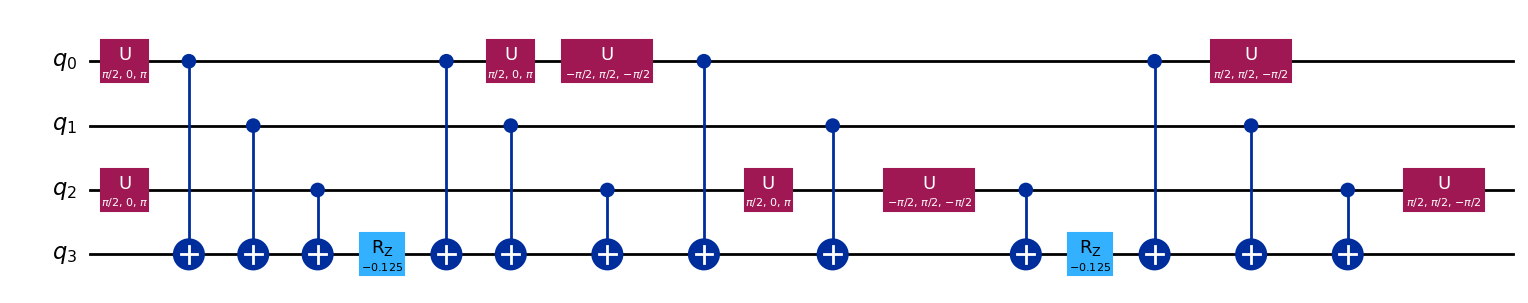

In [14]:
qc = QuantumCircuit(4)
qc.append(fermion_hopping(epsilon, 1), range(4))
qc.decompose().decompose().draw('mpl')

Clearly, $U_{fh}$ is much more expensive to implement than the $U_{kg}$ or $U_{fm}$.  Before we proceed to putting the entire circuit together, lets try and perform some benchmarking on this gate alone.  First, lets just run the gate once on a simulator and real machine to see how it works.

* To do this, create a QuantumCircuit with 4 qubits and 4 classical bits, apply your fermion_hopping gate with `epsilon` and `eta=1`.
* Run and get the counts output from the `AerSimulator()`.  Store the counts of your result in `sim_results`   

In [15]:
qc = QuantumCircuit(4, 4)
qc.append(fermion_hopping(epsilon, 1), range(4))
qc.measure(range(4), range(4))

sim_backend = AerSimulator()
tc = transpile(qc, sim_backend, optimization_level=3)
job = sim_backend.run(tc, shots=1024*4)
sim_result = job.result().get_counts()
sim_result

{'0000': 4096}

Plot your results, what did you find?

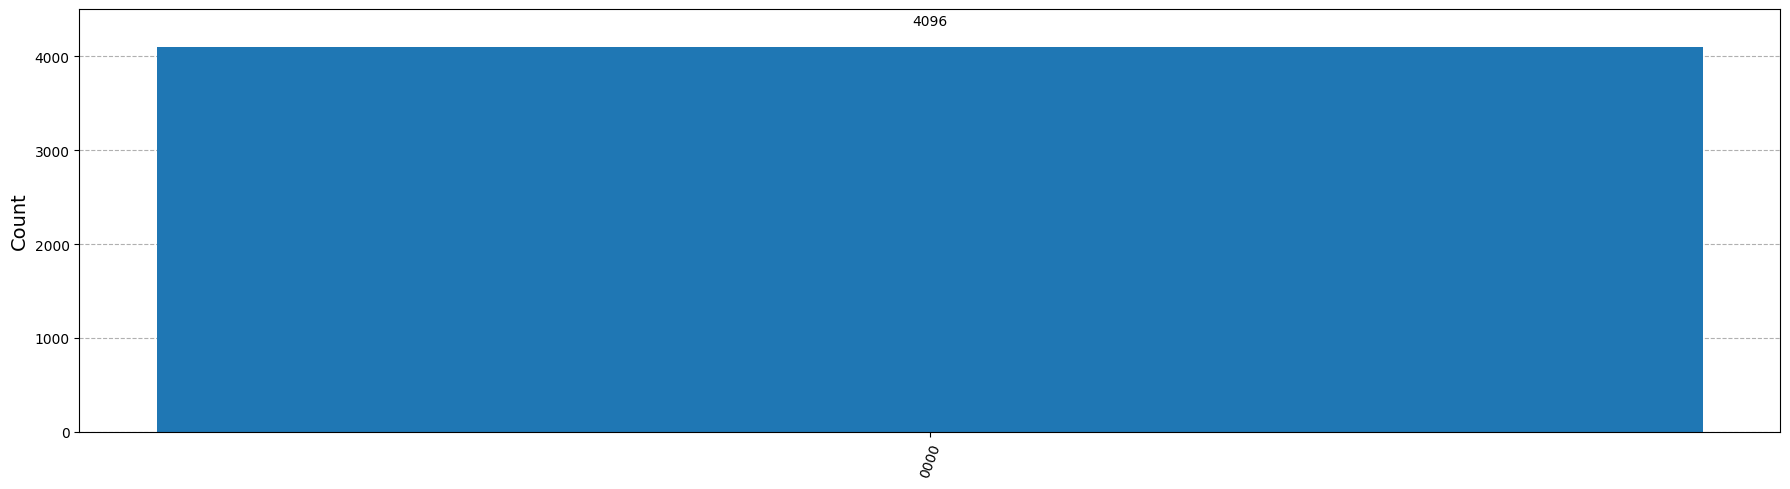

In [16]:
plot_histogram([sim_result], figsize=(18, 5))

On the noiseless simulator the histogram is a single bar at $|0000\rangle$ with probability 1. That is exactly what we expect: applying a single Trotter step of $U_{fh}$ to $|0000\rangle$ leaves the state in $|0000\rangle$ (the hopping term cannot create an electron–positron pair out of the vacuum at this order), so every shot returns the all-zeros bitstring. Any spread away from $|0000\rangle$ we later see on real hardware is therefore pure device noise.

If you got $|0000\rangle$, hooray!  It seems you have gotten your circuit to work.  Now to try running on a real machine:

*Look back at the Deutsch-Jozsa lab, there should be code for setting the backend to least_busy, to generate a pass manager, transpile, and then with the sampler run the job, while printing the job ID and status.  Copy that here -- making sure to put the right circuit name into the tranpiling.  After that, you could try and run your circuit --- but you might ask an instructor to check before you submit this job.

In [17]:
# Transpile + run on whatever backend get_backend() returned. On real hardware
# this submits a job to IBM; with the AerSimulator fallback it runs locally.
if service is not None:
    # Real IBM hardware path.
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    transpiled_circuit = pm.run(qc)
    sampler = Sampler(mode=backend)
    job = sampler.run([transpiled_circuit])
    print(f">>> Job ID: {job.job_id()}")
    print(f">>> Job Status: {job.status()}")
else:
    # Local-simulator fallback: run the same circuit on AerSimulator.
    tc = transpile(qc, backend, optimization_level=3)
    job = backend.run(tc, shots=1024*4)
    print(">>> Ran on local AerSimulator fallback.")

>>> Ran on local AerSimulator fallback.


Once your circuit has run, you can copy the job id below and then get the results into a variable called `real_result` which we will compare in a histogram below

In [18]:
# On real hardware, paste the job id printed above and fetch its result.
# With the simulator fallback we just read the local job's counts.
if service is not None:
    job_id = ''                       # <-- paste your IBM job id here
    job = service.job(job_id)
    real_result = job.result()[0].data.c.get_counts()
else:
    real_result = job.result().get_counts()
real_result

{'0000': 4096}

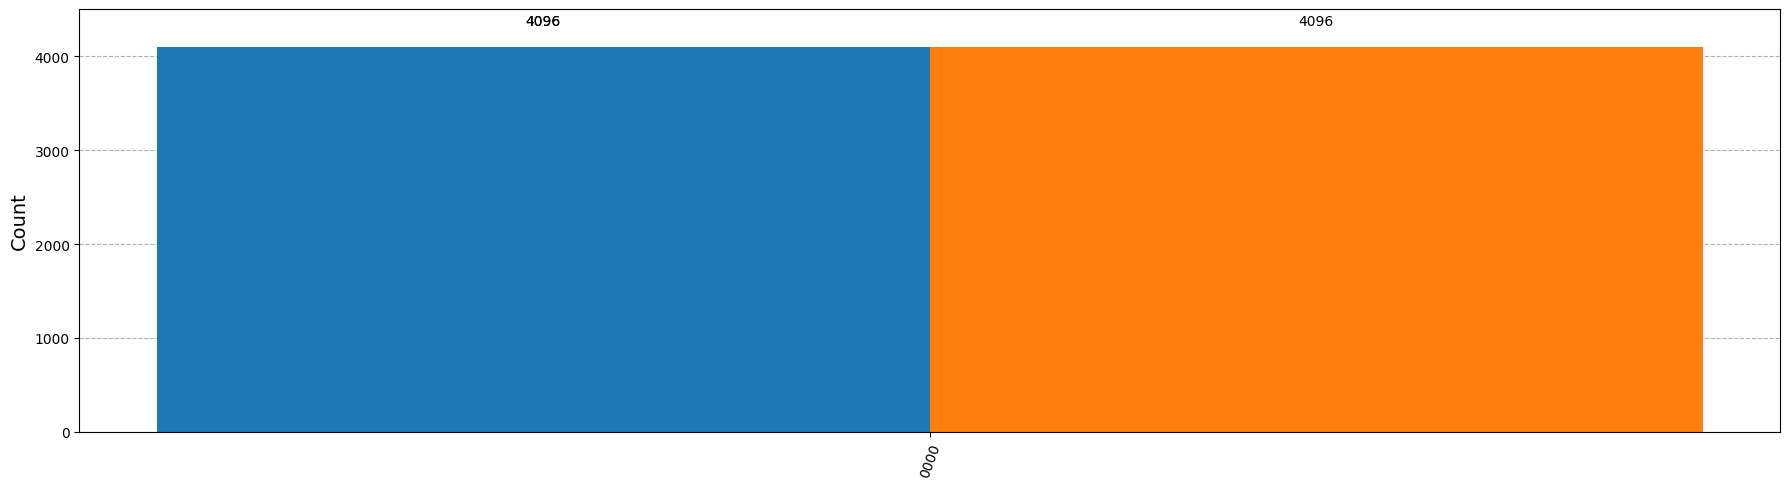

In [19]:
#If you call plot_histogram with a list [results1,results2,results3,...],
#you can plot multiple data sets side by side for comparison.  Do this for
#sim_result vs real_result.  How does the real device compare for this one step?
plot_histogram([sim_result, real_result], figsize=(18, 5))

Ponder for a moment, can I read off from this histogram all the information about the error rate of the $U_{fh}$ gate?  Are there reasons to think this analysis was inadequate?

Maybe you should worry that we only tested the error obtained when the gate was applied to $|0000\rangle$.  Perhaps other states are effected differently.  To test this, in the next cell, re-run the previous test, but prior to applying the $U_{fh}$ gate, initialize the electron, photon, and positron qubits with a $H$ gate.

Again, might ask an instructor to check before you wait an hour for results.

In [20]:
qc = QuantumCircuit(4, 4)
qc.h(range(3))
qc.append(fermion_hopping(epsilon, 1), range(4))
qc.measure(range(4), range(4))

# Noiseless reference on the simulator.
sim_backend = AerSimulator()
tc = transpile(qc, sim_backend, optimization_level=3)
job = sim_backend.run(tc, shots=1024*4)
sim_result = job.result().get_counts()

# Real-hardware run (or simulator fallback) of the same H-initialized circuit.
if service is not None:
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    transpiled_circuit = pm.run(qc)
    sampler = Sampler(mode=backend)
    job = sampler.run([transpiled_circuit])
    print(f">>> Job ID: {job.job_id()}")
    print(f">>> Job Status: {job.status()}")
else:
    job = backend.run(transpile(qc, backend, optimization_level=3), shots=1024*4)
    print(">>> Ran on local AerSimulator fallback.")

>>> Ran on local AerSimulator fallback.


Put in the job id, and store the results in real_result

In [21]:
if service is not None:
    job_id = ''                       # <-- paste your IBM job id here
    job = service.job(job_id)
    real_result = job.result()[0].data.c.get_counts()
else:
    real_result = job.result().get_counts()
real_result

{'0100': 507,
 '0110': 520,
 '0101': 501,
 '0111': 524,
 '0011': 516,
 '0001': 514,
 '0010': 505,
 '0000': 509}

*Gate fidelity* is a topic we have covered only briefly, but perhaps you already have some intuition for its meaning.  It refers to a group of metrics that measure how closely the gate gets to its expected result in the noiseless case.  

One method for computing one so-called *classical fidelity* $F_C$ is to take
$$F_C=\left(\sum_{i=0}^N \sqrt{p_{i,exact}*p_{i,measured}}\right)^2 $$
where $i$ indexes the possible states with the total number being $N=2^q$, $p_{i}$ indicates the probability of state $i$ with $exact$ indicating your noiseless simulator results while $measured$ indicates the real machine.  In the cell below, **compute the classical fidelity of your fermion hopping gate**.

A person familiar with python might use the `sum()` function as well as ` np.sqrt(sim_result[key])*np.sqrt(sim_result.[key]) for key in sim_result`



1.0
0.9998505768755891


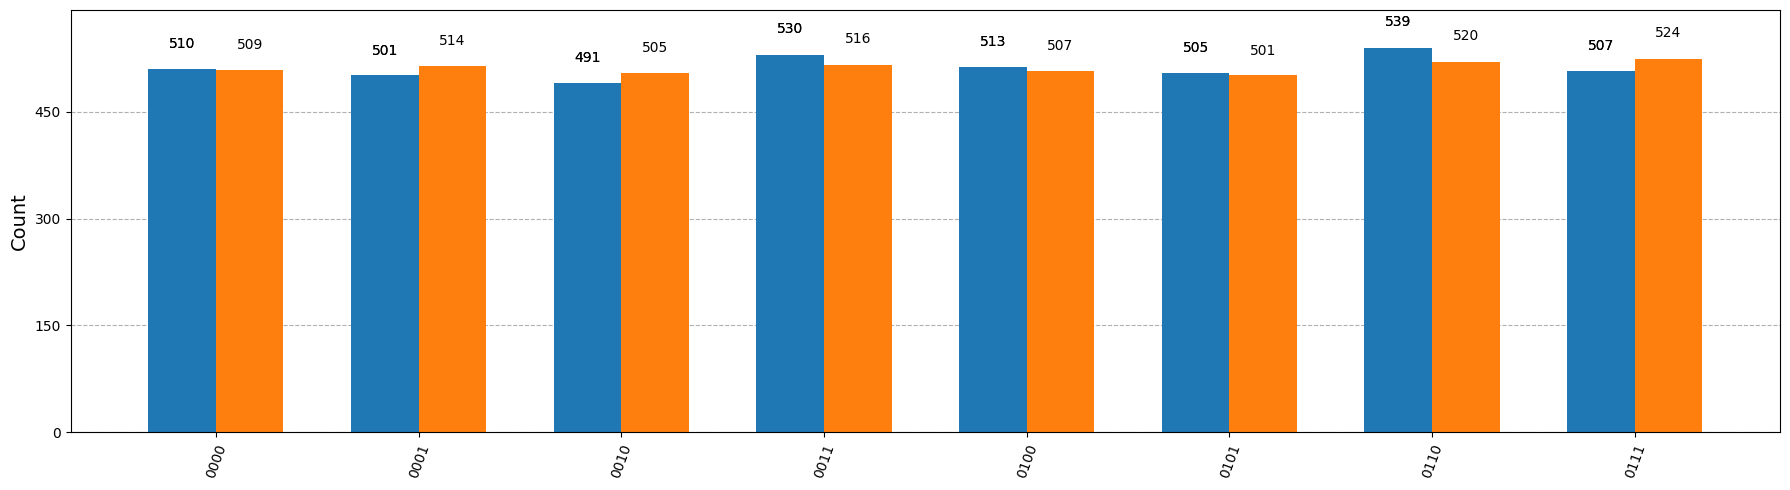

In [22]:
# Classical fidelity F_C = (sum_i sqrt(p_i,exact * p_i,measured))^2.
# Normalize counts by total shots (1024*4) per distribution.
shots = 1024 * 4
# self-overlap (== 1, a sanity check) and sim-vs-real overlap:
print(sum(np.sqrt(sim_result[key]) * np.sqrt(sim_result[key])
          for key in sim_result)**2 / shots**2)
print(sum(np.sqrt(sim_result[key]) * np.sqrt(real_result.get(key, 0))
          for key in sim_result)**2 / shots**2)
plot_histogram([sim_result, real_result], figsize=(18, 5))

So what fidelity did you get for your $U_{fh}$?  

In the next cell, can you estimate the number $N$ of $U_{fh}$ that you can apply before the fidelity $\mathcal{F}_{N}$ has dropped to 50%?  To do this, you can use the formula which assumes uncorrelated errors and the single gate fidelity $\mathcal{F}_{1}$:

$$\mathcal{F}_{N}=(\mathcal{F}_{1})^N$$

In [23]:
# Solve (F_1)^N = 0.5 for N, using an example single-gate fidelity F_1 = 0.9.
F_1 = 0.9
print(np.log(0.5) / np.log(F_1))

6.578813478960585


Did you get a huge number?  This value is certainly an upper bound on the total number of steps we can simulate our lattice field theory for.  

But remember, we have other gates we also need to include.  Further, assuming the errors in $U_{fh}$ are uncorrelated is in fact a relatively optimistic assumption -- the true $\mathcal{F}_N$ will be lower.